In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
raw_path = "../data/raw/time_series_60min_singleindex.csv"

In [3]:
cols_preview = pd.read_csv(raw_path, nrows=0).columns
print(cols_preview)

Index(['utc_timestamp', 'cet_cest_timestamp',
       'AT_load_actual_entsoe_transparency',
       'AT_load_forecast_entsoe_transparency', 'AT_price_day_ahead',
       'AT_solar_generation_actual', 'AT_wind_onshore_generation_actual',
       'BE_load_actual_entsoe_transparency',
       'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual',
       ...
       'SI_load_actual_entsoe_transparency',
       'SI_load_forecast_entsoe_transparency', 'SI_solar_generation_actual',
       'SI_wind_onshore_generation_actual',
       'SK_load_actual_entsoe_transparency',
       'SK_load_forecast_entsoe_transparency', 'SK_solar_generation_actual',
       'SK_wind_onshore_generation_actual',
       'UA_load_actual_entsoe_transparency',
       'UA_load_forecast_entsoe_transparency'],
      dtype='str', length=300)


In [4]:
de_cols = [col for col in cols_preview if "DE" in col or "utc_timestamp" in col]
df = pd.read_csv(raw_path, usecols=de_cols)

In [5]:
print(df.shape)
print(de_cols)
df.head()

(50401, 42)
['utc_timestamp', 'DE_load_actual_entsoe_transparency', 'DE_load_forecast_entsoe_transparency', 'DE_solar_capacity', 'DE_solar_generation_actual', 'DE_solar_profile', 'DE_wind_capacity', 'DE_wind_generation_actual', 'DE_wind_profile', 'DE_wind_offshore_capacity', 'DE_wind_offshore_generation_actual', 'DE_wind_offshore_profile', 'DE_wind_onshore_capacity', 'DE_wind_onshore_generation_actual', 'DE_wind_onshore_profile', 'DE_50hertz_load_actual_entsoe_transparency', 'DE_50hertz_load_forecast_entsoe_transparency', 'DE_50hertz_solar_generation_actual', 'DE_50hertz_wind_generation_actual', 'DE_50hertz_wind_offshore_generation_actual', 'DE_50hertz_wind_onshore_generation_actual', 'DE_LU_load_actual_entsoe_transparency', 'DE_LU_load_forecast_entsoe_transparency', 'DE_LU_price_day_ahead', 'DE_LU_solar_generation_actual', 'DE_LU_wind_generation_actual', 'DE_LU_wind_offshore_generation_actual', 'DE_LU_wind_onshore_generation_actual', 'DE_amprion_load_actual_entsoe_transparency', 'DE_a

,utc_timestamp,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,...,DE_tennet_load_actual_entsoe_transparency,DE_tennet_load_forecast_entsoe_transparency,DE_tennet_solar_generation_actual,DE_tennet_wind_generation_actual,DE_tennet_wind_offshore_generation_actual,DE_tennet_wind_onshore_generation_actual,DE_transnetbw_load_actual_entsoe_transparency,DE_transnetbw_load_forecast_entsoe_transparency,DE_transnetbw_solar_generation_actual,DE_transnetbw_wind_onshore_generation_actual
0,2014-12-31T23:00:00Z,NaN,NaN,37248.0,NaN,NaN,27913.0,NaN,NaN,667.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,41151.0,39723.0,37248.0,NaN,NaN,27913.0,8852.0,0.3171,667.0,...,13841.0,13362.0,NaN,3866.0,469.0,3398.0,5307.0,4703.0,NaN,5.0
2,2015-01-01T01:00:00Z,40135.0,38813.0,37248.0,NaN,NaN,27913.0,9054.0,0.3244,667.0,...,13267.0,12858.0,NaN,3974.0,466.0,3508.0,5087.0,4562.0,NaN,7.0
3,2015-01-01T02:00:00Z,39106.0,38490.0,37248.0,NaN,NaN,27913.0,9070.0,0.3249,667.0,...,12702.0,12611.0,NaN,4194.0,470.0,3724.0,4906.0,4517.0,NaN,8.0
4,2015-01-01T03:00:00Z,38765.0,38644.0,37248.0,NaN,NaN,27913.0,9163.0,0.3283,667.0,...,12452.0,12490.0,NaN,4446.0,473.0,3973.0,4865.0,4601.0,NaN,11.0


In [6]:
df.dtypes

utc_timestamp                                          str
DE_load_actual_entsoe_transparency                 float64
DE_load_forecast_entsoe_transparency               float64
DE_solar_capacity                                  float64
DE_solar_generation_actual                         float64
DE_solar_profile                                   float64
DE_wind_capacity                                   float64
DE_wind_generation_actual                          float64
DE_wind_profile                                    float64
DE_wind_offshore_capacity                          float64
DE_wind_offshore_generation_actual                 float64
DE_wind_offshore_profile                           float64
DE_wind_onshore_capacity                           float64
DE_wind_onshore_generation_actual                  float64
DE_wind_onshore_profile                            float64
DE_50hertz_load_actual_entsoe_transparency         float64
DE_50hertz_load_forecast_entsoe_transparency       float

In [7]:
# Converting timestamp
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp']) 

In [8]:
print(df.isnull().sum().sort_values(ascending=False))

DE_LU_load_forecast_entsoe_transparency            33745
DE_LU_load_actual_entsoe_transparency              32877
DE_LU_solar_generation_actual                      32862
DE_LU_price_day_ahead                              32861
DE_LU_wind_offshore_generation_actual              32855
DE_LU_wind_generation_actual                       32855
DE_LU_wind_onshore_generation_actual               32855
DE_solar_profile                                    6705
DE_wind_offshore_profile                            6676
DE_wind_profile                                     6676
DE_wind_onshore_profile                             6674
DE_wind_onshore_capacity                            6601
DE_solar_capacity                                   6601
DE_wind_offshore_capacity                           6601
DE_wind_capacity                                    6601
DE_solar_generation_actual                           104
DE_wind_offshore_generation_actual                    75
DE_wind_generation_actual      

### 1. The "DE_LU" Problem (~33,000 Nulls)
Look at those top 7 rows. Over 32,000 missing values is massive.

* **The Reason:** The "DE_LU" (Germany-Luxembourg) bidding zone was only created in October 2018. Since your dataset starts in 2015, those first three years simply don't exist for these columns.

* **The Engineering Decision:** Let's keep the full timeline for Load, but we must be careful not to show "0" for price before 2018; it should stay as "Null" or "Data Unavailable."

### 2. The "Profile" and "Capacity" Nulls (~6,600 Nulls)
These columns (Solar/Wind Capacity) have about 6,700 missing values.

* **The Reason:** These are usually updated monthly or yearly, not every hour.

* **The Engineering Decision:** In our ETL, we should use Forward Fill (ffill) for Capacity. If we know the solar capacity was 40GW on Monday, it’s still 40GW on Tuesday. Interpolation doesn't make sense here, but carrying the last known value forward does.

### 3. The "Actuals" (1 - 100 Nulls)
Columns like DE_solar_generation_actual (104 nulls) or DE_tennet_load (8 nulls) are just "Sensor Glitches."

* **The Engineering Decision:** Linear Interpolation. This is where we draw a line between the hour before and the hour after. Because energy flow is continuous, this is the most accurate way to "guess" the missing hour.

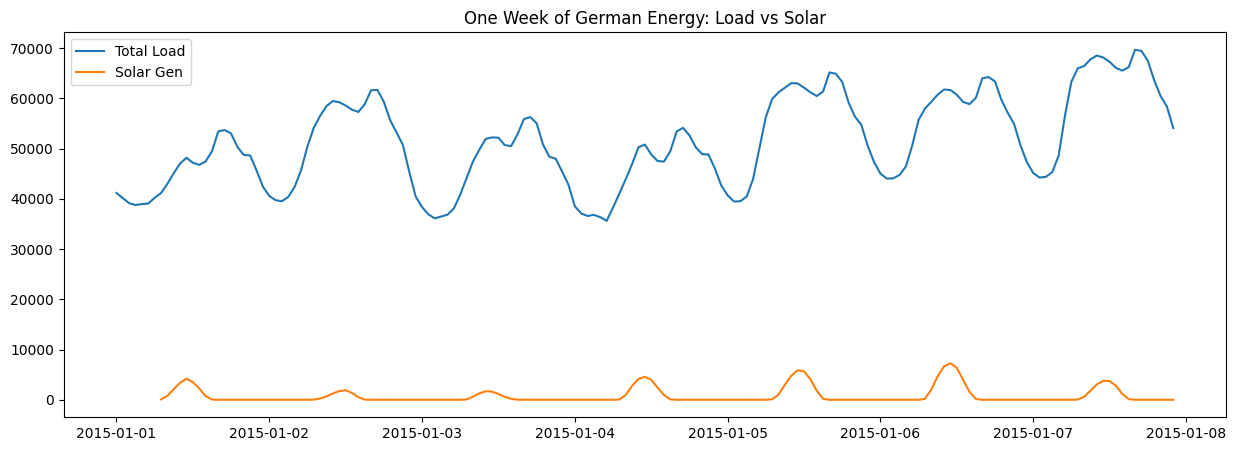

In [9]:
plt.figure(figsize=(15,5))
plt.plot(df['utc_timestamp'][:168], df['DE_load_actual_entsoe_transparency'][:168], label='Total Load')
plt.plot(df['utc_timestamp'][:168], df['DE_solar_generation_actual'][:168], label='Solar Gen')
plt.title("One Week of German Energy: Load vs Solar")
plt.legend()
plt.show()


In [10]:
df.tail() # The data is from 2015 to 2020

,utc_timestamp,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,...,DE_tennet_load_actual_entsoe_transparency,DE_tennet_load_forecast_entsoe_transparency,DE_tennet_solar_generation_actual,DE_tennet_wind_generation_actual,DE_tennet_wind_offshore_generation_actual,DE_tennet_wind_onshore_generation_actual,DE_transnetbw_load_actual_entsoe_transparency,DE_transnetbw_load_forecast_entsoe_transparency,DE_transnetbw_solar_generation_actual,DE_transnetbw_wind_onshore_generation_actual
50396,2020-09-30 19:00:00+00:00,57559.0,56708.0,NaN,0.0,NaN,NaN,10654.0,NaN,NaN,...,17719.0,17190.0,0.0,8186.0,4628.0,3558.0,7657.0,7428.0,NaN,164.0
50397,2020-09-30 20:00:00+00:00,54108.0,53270.0,NaN,0.0,NaN,NaN,11836.0,NaN,NaN,...,16984.0,16446.0,0.0,8879.0,5056.0,3824.0,7072.0,6870.0,NaN,242.0
50398,2020-09-30 21:00:00+00:00,49845.0,49239.0,NaN,0.0,NaN,NaN,12168.0,NaN,NaN,...,15549.0,15256.0,0.0,8972.0,5165.0,3807.0,6465.0,6388.0,NaN,257.0
50399,2020-09-30 22:00:00+00:00,46886.0,46620.0,NaN,0.0,NaN,NaN,12533.0,NaN,NaN,...,14595.0,14586.0,0.0,9049.0,5123.0,3925.0,5963.0,5958.0,NaN,304.0
50400,2020-09-30 23:00:00+00:00,45461.0,44986.0,NaN,0.0,NaN,NaN,12798.0,NaN,NaN,...,14241.0,14062.0,0.0,9162.0,5124.0,4038.0,5668.0,5735.0,NaN,342.0


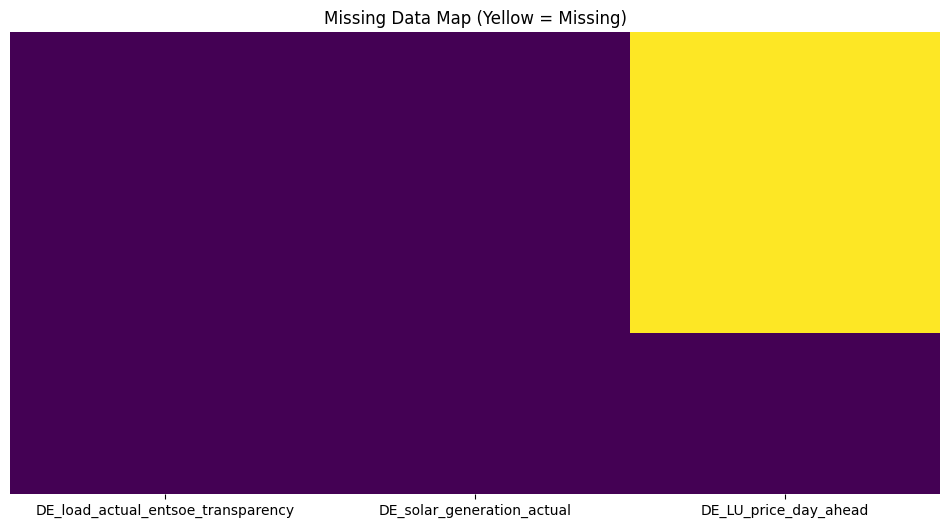

In [11]:
import seaborn as sns

# Pick a few key columns to check the "Missingness Map"
check_cols = [
    'DE_load_actual_entsoe_transparency', 
    'DE_solar_generation_actual', 
    'DE_LU_price_day_ahead'
]

plt.figure(figsize=(12, 6))
sns.heatmap(df[check_cols].isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Data Map (Yellow = Missing)")
plt.show()

Since the DE_LU bidding zone didn't exist until late 2018, everything before that is mathematically non-existent.

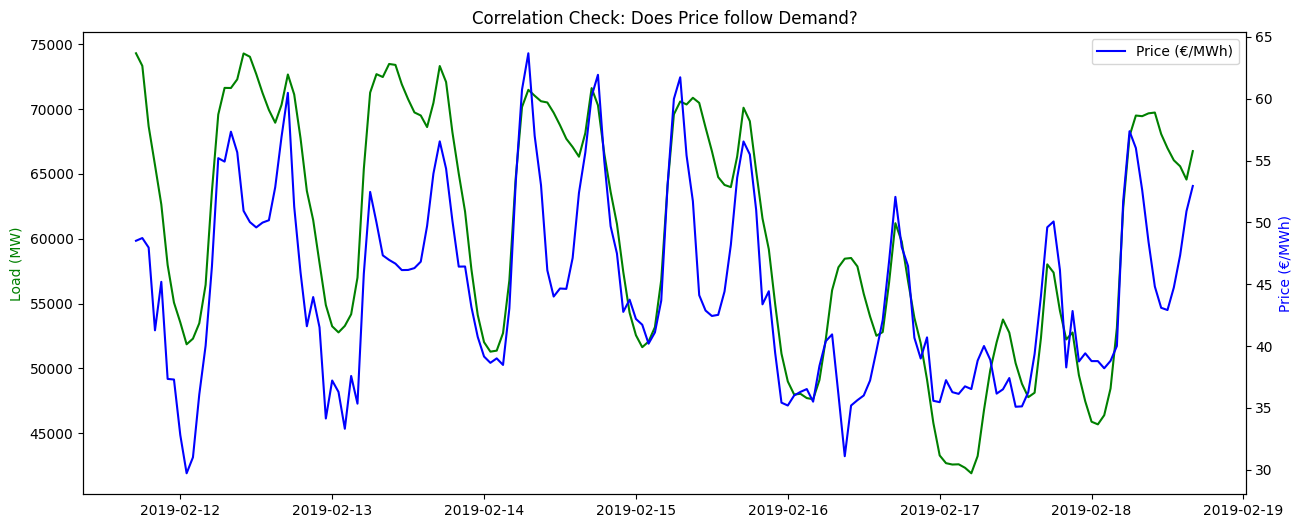

In [12]:
# Create a slice from 2019 onwards where DE_LU data is actually present
df_modern = df[df['utc_timestamp'] > '2019-01-01'].copy()

# Plot Price vs Load for a week
sample = df_modern.iloc[1000:1168] # One week

fig, ax1 = plt.subplots(figsize=(15, 6))

ax2 = ax1.twinx()
ax1.plot(sample['utc_timestamp'], sample['DE_load_actual_entsoe_transparency'], color='g', label='Load (Demand)')
ax2.plot(sample['utc_timestamp'], sample['DE_LU_price_day_ahead'], color='b', label='Price (€/MWh)')

ax1.set_ylabel('Load (MW)', color='g')
ax2.set_ylabel('Price (€/MWh)', color='b')
plt.title("Correlation Check: Does Price follow Demand?")
plt.legend()
plt.show()

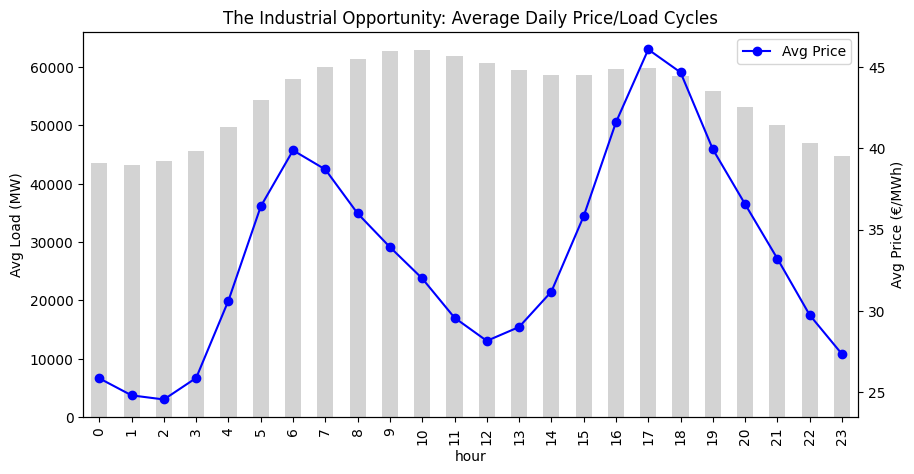

In [13]:
# Group by hour to find the "Typical Day"
df_modern['hour'] = df_modern['utc_timestamp'].dt.hour
typical_day = df_modern.groupby('hour')[['DE_load_actual_entsoe_transparency', 'DE_LU_price_day_ahead']].mean()

# Plotting the "Average Factory Day"
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

typical_day['DE_load_actual_entsoe_transparency'].plot(kind='bar', ax=ax1, color='lightgray', label='Avg Load')
typical_day['DE_LU_price_day_ahead'].plot(ax=ax2, marker='o', color='blue', label='Avg Price')

ax1.set_ylabel('Avg Load (MW)')
ax2.set_ylabel('Avg Price (€/MWh)')
plt.title("The Industrial Opportunity: Average Daily Price/Load Cycles")
plt.legend()
plt.show()

"Double Peak" (Morning at 8 AM and Evening at 5 PM).

In [14]:
# 41 columns into 3 columns: Timestamp, Sensor_Name, and Value
df_long = df.melt(id_vars=['utc_timestamp'], var_name='metric', value_name='value')

In [15]:
df_long

,utc_timestamp,metric,value
0,2014-12-31 23:00:00+00:00,DE_load_actual_entsoe_transparency,NaN
1,2015-01-01 00:00:00+00:00,DE_load_actual_entsoe_transparency,41151.0
2,2015-01-01 01:00:00+00:00,DE_load_actual_entsoe_transparency,40135.0
3,2015-01-01 02:00:00+00:00,DE_load_actual_entsoe_transparency,39106.0
4,2015-01-01 03:00:00+00:00,DE_load_actual_entsoe_transparency,38765.0
...,...,...,...
2066436,2020-09-30 19:00:00+00:00,DE_transnetbw_wind_onshore_generation_actual,164.0
2066437,2020-09-30 20:00:00+00:00,DE_transnetbw_wind_onshore_generation_actual,242.0
2066438,2020-09-30 21:00:00+00:00,DE_transnetbw_wind_onshore_generation_actual,257.0
2066439,2020-09-30 22:00:00+00:00,DE_transnetbw_wind_onshore_generation_actual,304.0


In [16]:
df_long.isnull().sum()

utc_timestamp         0
metric                0
value            284490
dtype: int64

In [17]:
df_long['value'] = df_long.groupby('metric')['value'].transform(
        lambda x: x.interpolate(method='linear', limit=2)
)

In [18]:
df_long.isnull().sum()

utc_timestamp         0
metric                0
value            284347
dtype: int64

In [19]:
df_long

,utc_timestamp,metric,value
0,2014-12-31 23:00:00+00:00,DE_load_actual_entsoe_transparency,NaN
1,2015-01-01 00:00:00+00:00,DE_load_actual_entsoe_transparency,41151.0
2,2015-01-01 01:00:00+00:00,DE_load_actual_entsoe_transparency,40135.0
3,2015-01-01 02:00:00+00:00,DE_load_actual_entsoe_transparency,39106.0
4,2015-01-01 03:00:00+00:00,DE_load_actual_entsoe_transparency,38765.0
...,...,...,...
2066436,2020-09-30 19:00:00+00:00,DE_transnetbw_wind_onshore_generation_actual,164.0
2066437,2020-09-30 20:00:00+00:00,DE_transnetbw_wind_onshore_generation_actual,242.0
2066438,2020-09-30 21:00:00+00:00,DE_transnetbw_wind_onshore_generation_actual,257.0
2066439,2020-09-30 22:00:00+00:00,DE_transnetbw_wind_onshore_generation_actual,304.0
